# Prepare Dataset

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear
from scipy.signal import savgol_filter
from scipy.ndimage import zoom
from tqdm import tqdm

def get_resultx(white,all_spec):
    bounds = (0, np.inf)
    cur_result = lsq_linear(all_spec.T,white,bounds=bounds).x
    result = np.zeros((10,cur_result.shape[0]))
    result[0] = cur_result
    for i in range(result.shape[0]):
        result[i] = savgol_filter(cur_result,i*5+5,1)
    result[:,610:] = 0
    return result
    
print("Loading monochromatic data")
imgs = []
for i in tqdm(range(1,9)):
    fo = np.load("./data%d.npz"%i)
    cur_imgs = fo["arr_0"].astype(np.float32)
    cur_exp = fo["arr_1"]
    for j in range(cur_exp.shape[0]):
        imgs.append(zoom(cur_imgs[j]/cur_exp[j],
                         (448/cur_imgs[j].shape[0],448/cur_imgs[j].shape[1])).astype(np.float32))

fo = np.load("./spectrums.npz")
all_spec = fo["arr_0"]

def get_train_aug(name,white_i):
    white_spec = np.load(name+"_spec.npz")["arr_0"]
    fo = np.load(name+"_imgs.npz")
    white_mean = np.mean(np.mean(fo["arr_0"],-1),-1)/fo["arr_1"]
    
    x_train_aug = []
    y_train_aug = []
    for i in tqdm(range(len(white_i))):
        resultx = get_resultx(white_spec[white_i[i]],all_spec)
        for j in range(10):
            cur_y = np.zeros_like(all_spec[0])
            cur_x = np.zeros((1,448,448))
            for k in range(resultx.shape[1]):
                cur_y += all_spec[k]*resultx[j,k]
                cur_x += imgs[k]*resultx[j,k]
            cur_x = white_mean[white_i[i]]/np.mean(cur_x)*cur_x
            cur_y = savgol_filter(cur_y,30,1)
            x_train_aug.append(cur_x)
            y_train_aug.append(cur_y)
    x_train_aug = np.stack(x_train_aug).astype(np.float32)
    y_train_aug = np.stack(y_train_aug).astype(np.float32)
    
    return x_train_aug,y_train_aug

print("Loading white")
white_i = [2,3,4,5,6,7]
name1="white"
x_aug1,y_aug1 = get_train_aug(name1,white_i)
print("Loading dye1")
dye1_i = [2,3,4,5,6,7,8,9]
name2 = "dye1"
x_aug2,y_aug2 = get_train_aug(name2,dye1_i)
print("Loading dye2")
name3 = "dye2"
dye2_i = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]
x_aug3,y_aug3 = get_train_aug(name3,dye2_i)

x_train_aug = np.concatenate([x_aug1,x_aug2,x_aug3])
y_train_aug = np.concatenate([y_aug1,y_aug2,y_aug3])
np.savez_compressed("train_aug_new.npz",x_train_aug,y_train_aug)

Loading monochromatic data


100%|██████████| 8/8 [00:34<00:00,  4.28s/it]


Loading white


100%|██████████| 6/6 [00:33<00:00,  5.54s/it]


Loading dye1


100%|██████████| 8/8 [00:44<00:00,  5.62s/it]


Loading dye2


100%|██████████| 14/14 [01:18<00:00,  5.58s/it]


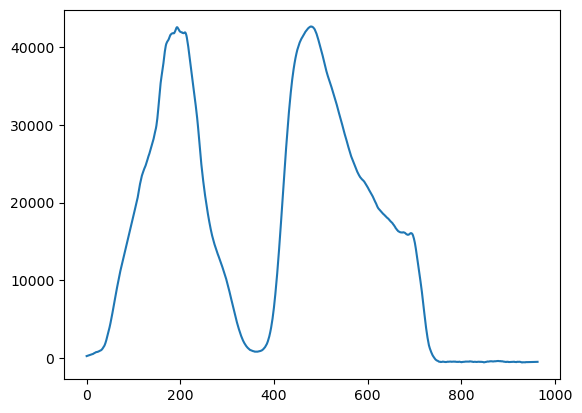

In [38]:
import numpy as np
import matplotlib.pyplot as plt

y_aug = np.load("./train_aug_new.npz")["arr_1"]
plt.plot(y_aug[80])
#plt.plot(savgol_filter(y_aug[60],30,1))

In [32]:
def get_testval_aug(names,white_is):
    x_val_aug = []
    x_test_aug = []
    y_val_aug = []
    y_test_aug = []
    for n in range(len(names)):
        name = names[n]
        white_i = white_is[n]
        white_spec = np.load(name+"_spec.npz")["arr_0"].astype(np.float32)
        fo = np.load(name+"_imgs.npz")
        cur_imgs = fo["arr_0"]
        cur_exp = fo["arr_1"]
        white_imgs = np.zeros((len(white_i),1,448,448),dtype=np.float32)
        idx = 0
        for i in white_i:
            white_imgs[idx,0] = zoom(cur_imgs[i]/cur_exp[i],(448/cur_imgs.shape[1],448/cur_imgs.shape[2])).astype(np.float32)
            idx += 1
        test_i = []
        val_i = []
        for i in range(len(white_i)):
            if i%2 == 0:
                test_i.append(i)
            else:
                val_i.append(i)
        
        x_val_aug.append(white_imgs[val_i])
        y_val_aug.append(white_spec[val_i])
        x_test_aug.append(white_imgs[test_i])
        y_test_aug.append(white_spec[test_i])
    x_val_aug = np.concatenate(x_val_aug)
    y_val_aug = np.concatenate(y_val_aug)
    x_test_aug = np.concatenate(x_test_aug)
    y_test_aug = np.concatenate(y_test_aug)
        
    return x_val_aug,y_val_aug,x_test_aug,y_test_aug

x_val_aug,y_val_aug,x_test_aug,y_test_aug = get_testval_aug(["white","dye1","dye2"],[white_i,dye1_i,dye2_i])
np.savez_compressed("./valtest_aug.npz",x_val_aug,y_val_aug,x_test_aug,y_test_aug)

# Post-process

In [1]:
import sys
import numpy as np
import torch
from scipy.ndimage import zoom
from torch import nn
import pandas as pd

seed = 324
nn_input_size = 448
save_dir="./ML_result/"

print("Using seed",seed)
print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
sys.stdout.flush()

np.random.seed(seed)
torch.manual_seed(seed)

class BasicBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride= 1,expansion = 1,downsample= None):
        super(BasicBlock, self).__init__()
        # Multiplicative factor for the subsequent conv2d layer's output channels.
        # It is 1 for ResNet18 and ResNet34.
        self.expansion = expansion
        self.downsample = downsample
        self.conv1 = nn.Conv2d(
            in_channels, 
            out_channels, 
            kernel_size=3, 
            stride=stride, 
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, 
            out_channels*self.expansion, 
            kernel_size=3, 
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels*self.expansion)
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return  out
        
class ResNet18(nn.Module):
    def __init__(self,img_channels=1,block=BasicBlock,num_classes = 964):
        super(ResNet18, self).__init__()
        num_layers = 18
        layers = [2, 2, 2, 2]
        self.expansion = 1
        
        self.in_channels = 64
        # All ResNets (18 to 152) contain a Conv2d => BN => ReLU for the first
        # three layers. Here, kernel size is 7.
        self.conv1 = nn.Conv2d(
            in_channels=img_channels,
            out_channels=self.in_channels,
            kernel_size=7, 
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc = nn.Linear(2048*self.expansion, num_classes)
        
    def _make_layer(self,block,out_channels,blocks,stride = 1):
        downsample = None
        if stride != 1:
            """
            This should pass from `layer2` to `layer4` or 
            when building ResNets50 and above. Section 3.3 of the paper
            Deep Residual Learning for Image Recognition
            (https://arxiv.org/pdf/1512.03385v1.pdf).
            """
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, 
                    out_channels*self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False 
                ),
                nn.BatchNorm2d(out_channels * self.expansion),
            )
        layers = []
        layers.append(
            block(
                self.in_channels, out_channels, stride, self.expansion, downsample
            )
        )
        self.in_channels = out_channels * self.expansion
        for i in range(1, blocks):
            layers.append(block(
                self.in_channels,
                out_channels,
                expansion=self.expansion
            ))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # The spatial dimension of the final layer's feature 
        # map should be (7, 7) for all ResNets.
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    
print("Loading dataset")
print("Loading monochromatic data")
sys.stdout.flush()
fo = np.load("./spectrums.npz")
all_y = fo["arr_0"].astype(np.float32)
wl_x = fo["arr_2"]
imgs = np.zeros((all_y.shape[0],1,nn_input_size,nn_input_size),dtype=np.float32)
for i in range(1,9):
    fo = np.load("./data%d.npz"%i)
    cur_imgs = fo["arr_0"].astype(np.float32)
    cur_exp = fo["arr_1"]
    for j in range(cur_exp.shape[0]):
        imgs[(i-1)*100+j,0] = zoom(cur_imgs[j]/cur_exp[j],
                                (448/cur_imgs[j].shape[0],448/cur_imgs[j].shape[1])).astype(np.float32)
imgs = np.stack(imgs)
x_norm = np.mean(imgs)
y_norm = np.max(all_y)

print("Loading broadband data")
sys.stdout.flush()
test_i = np.arange(5,all_y.shape[0],10)
val_i = np.arange(9,all_y.shape[0],10)
train_i = []
for i in range(all_y.shape[0]):
    if i%10 !=5 and i%10!=9:
        train_i.append(i)
train_i = np.array(train_i)

x_val = imgs[val_i]
x_test = imgs[test_i]
y_val = all_y[val_i]
y_test = all_y[test_i]


fo = np.load("./valtest_aug.npz")
x_val = np.concatenate([x_val,fo["arr_0"]])
y_val = np.concatenate([y_val,fo["arr_1"]])
x_test = np.concatenate([x_test,fo["arr_0"]])
y_test = np.concatenate([y_test,fo["arr_1"]])

print("Converting to Pytorch")
sys.stdout.flush()
x_val = x_val/x_norm
x_test = x_test/x_norm
y_val = y_val/y_norm
y_test = y_test/y_norm

x_val = torch.from_numpy(x_val).to(device)
x_test = torch.from_numpy(x_test).to(device)

print("Making prediction")
model = torch.load("./ML_result/ResNet_seed324.pt",map_location="cpu")
model.eval()
with torch.no_grad():
    y_pred = model(x_test).to("cpu").detach().numpy()
x_test = x_test.to("cpu").detach().numpy()
np.savez_compressed("./y_pred.npz",y_pred,y_test,wl_x,x_test)

Using seed 324
Using torch 2.5.1
Using device: cpu
Loading dataset
Loading monochromatic data
Loading broadband data
Converting to Pytorch
Making prediction


/var/folders/dx/ypjj7qg52dg6jk1ct493lg2c0000gn/T/ipykernel_3400/3096497276.py:188: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("./ML_result/ResNet_seed3

# Plot

In [2]:
import numpy as np

fo = np.load("./y_pred.npz")
y_pred = fo["arr_0"]
y_test = fo["arr_1"]
wl_x = fo["arr_2"]
x_test = fo["arr_3"]

y_pred = y_pred/np.max(y_pred,1)[:,None]
y_test = y_test/np.max(y_test,1)[:,None]

broad_id = [-1,-2,-3,-4,-5,-6,-8,-9,-10,-12,-13]

print(y_test.shape)
def calc_MAE(predicted, true):
    numerator = np.mean(np.abs(predicted - true),-1)
    denominator = np.max(true)
    #denominator = np.sum(np.abs(true),-1)
    return numerator / denominator

def calc_RMSE(predicted, true):
    norm_scale = np.max(true)
    numerator = np.mean(np.square((predicted - true)/norm_scale),-1)

    return np.sqrt(numerator)

def calc_L1(predicted, true):
    numerator = np.sum(np.abs(predicted - true),-1)
    denominator = np.sum(np.abs(true),-1)
    return numerator/denominator

broad_error = calc_RMSE(y_pred[broad_id], y_test[broad_id])
peak_error = calc_RMSE(y_pred[:-14], y_test[:-14])
broad_error.mean(),peak_error.mean()

(92, 964)


(0.0512237, 0.008140926)

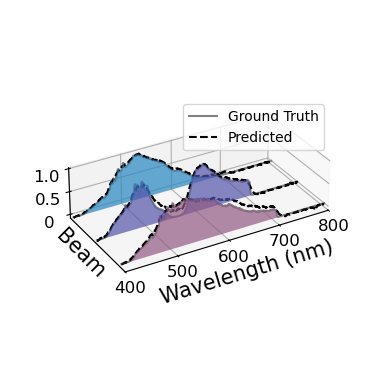

In [19]:
import matplotlib.pyplot as plt
import numpy as np

idxs = [-2,-8,-13]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
n_res = wl_x.shape[0]

ax = plt.figure().add_subplot(projection='3d')

for i in range(len(idxs)):
    idx = idxs[i]
    ys = np.ones_like(wl_x)*i
    ax.fill_between(wl_x, ys, y_test[idx],
                    wl_x, ys, 0,
                    facecolors=colors[i], alpha=.7)
    if i == 0:
        ax.plot(wl_x,ys,zs=y_test[idx],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx],ls="--",color="black")
ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([])
ax.set_zticks([0,0.5,1],[str(i) for i in [0,0.5,1.0]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)

ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=20)
ax.set_ylabel("Beam",fontsize=15,labelpad=-10,rotation=-45)
ax.set_box_aspect([2,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.45,0.6))

plt.savefig("beam1.svg",transparent=True, bbox_inches='tight')

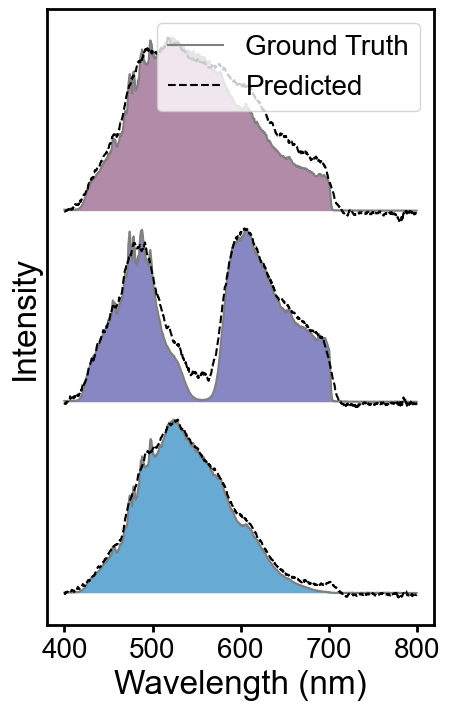

In [50]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.figure(figsize=(5, 8))

i=0
idx = idxs[i]
plt.plot(wl_x,y_test[idx],c="gray",label="Ground Truth")
plt.plot(wl_x,y_pred[idx],ls="--",color="black",label="Predicted")
plt.fill_between(wl_x, y_test[idx], np.zeros_like(wl_x),
                 facecolors=colors[i], alpha=0.7)
for i in range(1,len(idxs)):
    idx = idxs[i]
    plt.plot(wl_x,y_test[idx]+i*1.1,c="gray")
    plt.plot(wl_x,y_pred[idx]+i*1.1,ls="--",color="black")
    plt.fill_between(wl_x, y_test[idx]+i*1.1, i*1.1,
                    facecolors=colors[i], alpha=0.7)
plt.legend(fontsize=20,loc=1)
plt.yticks([])
plt.xticks([400,500,600,700,800],fontsize=20)
plt.xlabel("Wavelength (nm)",fontsize=24)
plt.ylabel("Intensity",fontsize=24)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./beam1.svg",transparent=True,bbox_inches="tight")

plt.show()

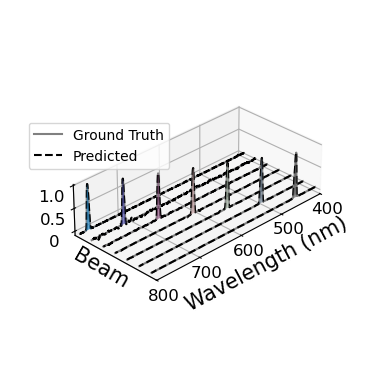

In [22]:
import matplotlib.pyplot as plt
import numpy as np

idxs = [9,20,31,42,53,64,75][::-1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
n_res = wl_x.shape[0]

ax = plt.figure().add_subplot(projection='3d')
for i in range(len(idxs)):
    idx = idxs[i]
    ys = np.ones_like(wl_x)*i
    ax.fill_between(wl_x, ys, y_test[idx],
                    wl_x, ys, 0,
                    facecolors=colors[i], alpha=0.7)
    if i == 0:
        ax.plot(wl_x,ys,zs=y_test[idx],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[idx],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[idx],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[idx],ls="--",color="black")
ax.view_init(elev=30, azim=45, roll=0)
ax.set_xlim(400,800)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([])
ax.set_zticks([0,0.5,1],[str(i) for i in [0,0.5,1.0]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)

ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=20)
ax.set_ylabel("Beam",fontsize=15,labelpad=-10,rotation=-30)
ax.set_box_aspect([2,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.45,0.55))

plt.savefig("beam2.svg",transparent=True, bbox_inches='tight')

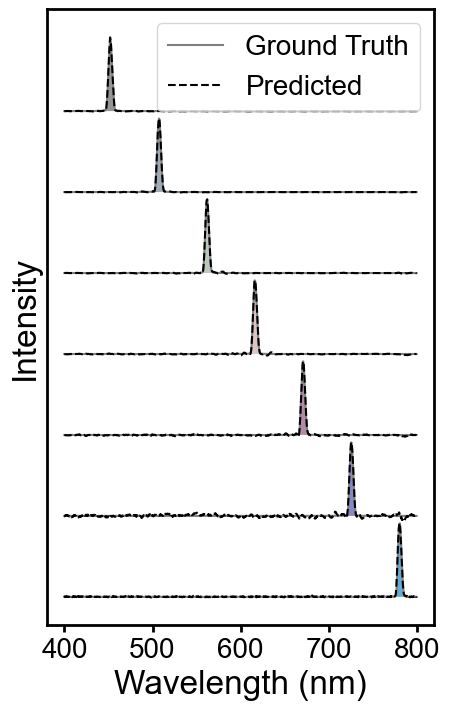

In [54]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.figure(figsize=(5, 8))

i=0
idx = idxs[i]
plt.plot(wl_x,y_test[idx],c="gray",label="Ground Truth")
plt.plot(wl_x,y_pred[idx],ls="--",color="black",label="Predicted")
plt.fill_between(wl_x, y_test[idx], np.zeros_like(wl_x),
                 facecolors=colors[i], alpha=0.7)
for i in range(1,len(idxs)):
    idx = idxs[i]
    plt.plot(wl_x,y_test[idx]+i*1.1,c="gray")
    plt.plot(wl_x,y_pred[idx]+i*1.1,ls="--",color="black")
    plt.fill_between(wl_x, y_test[idx]+i*1.1, i*1.1,
                    facecolors=colors[i], alpha=0.7)
plt.legend(fontsize=20,loc=1)
plt.yticks([])
plt.xticks([400,500,600,700,800],fontsize=20)
plt.xlabel("Wavelength (nm)",fontsize=24)
plt.ylabel("Intensity",fontsize=24)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./beam2.svg",transparent=True,bbox_inches="tight")

plt.show()

([], [])

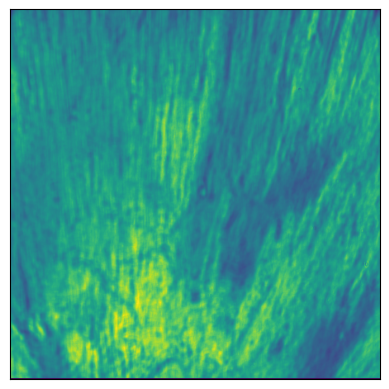

In [53]:
import matplotlib.pyplot as plt
import numpy as np

idxs = [9,20,31,42,53,64,75][::-1]

plt.imshow(x_test[idxs[-1],0])
plt.xticks([])
plt.yticks([])

([], [])

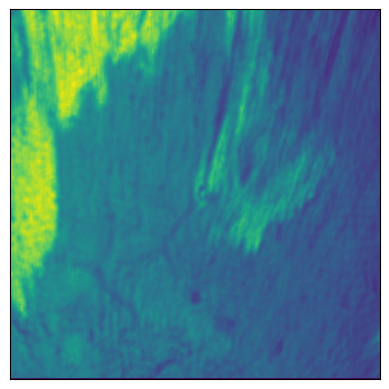

In [16]:
plt.imshow(x_test[idxs[-3],0])
plt.xticks([])
plt.yticks([])

([], [])

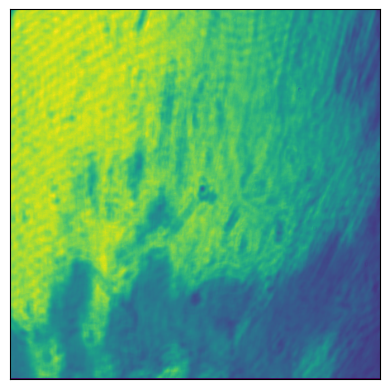

In [17]:
plt.imshow(x_test[idxs[-5],0])
plt.xticks([])
plt.yticks([])

0.22378376


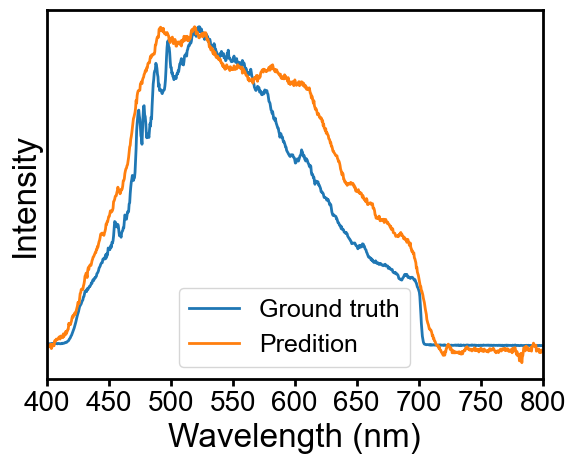

In [48]:
import matplotlib.pyplot as plt

idx = -12
5
plt.rcParams['font.sans-serif'] = ['Arial']

plt.plot(wl_x,y_test[idx],lw=2,label="Ground truth")
plt.plot(wl_x,y_pred[idx],lw=2,label="Predition")
MAE = np.sum(np.abs(y_pred[idx]-y_test[idx]))/np.sum(y_test[idx])
print(MAE)

plt.legend(fontsize=18)
plt.yticks([])
plt.xticks(fontsize=20)
plt.xlim(400,800)
plt.ylabel("Intensity",fontsize=24)
plt.xlabel("Wavelength (nm)",fontsize=24)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./spec_all.svg",transparent=True,bbox_inches="tight")

plt.show()

0.12643494


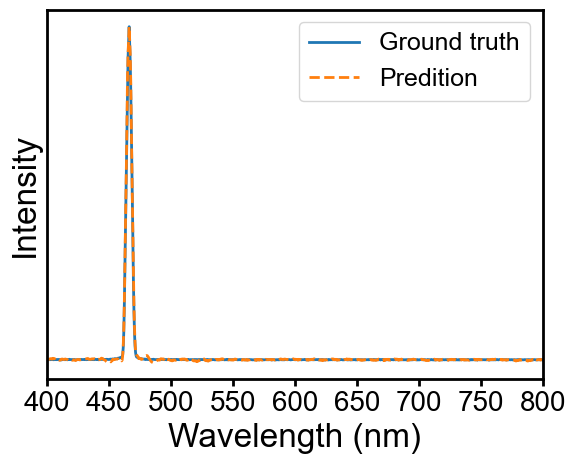

In [39]:
import matplotlib.pyplot as plt

idx = 12

plt.rcParams['font.sans-serif'] = ['Arial']

plt.plot(wl_x,y_test[idx],lw=2,label="Ground truth")
plt.plot(wl_x,y_pred[idx],"--",lw=2,label="Predition")
MAE = np.sum(np.abs(y_pred[idx]-y_test[idx]))/np.sum(y_test[idx])
print(MAE)

plt.legend(fontsize=18)
plt.yticks([])
plt.xticks(fontsize=20)
plt.xlim(400,800)
plt.ylabel("Intensity",fontsize=24)
plt.xlabel("Wavelength (nm)",fontsize=24)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./spec_all.svg",transparent=True,bbox_inches="tight")

plt.show()

In [38]:
92-14

78

In [35]:
fo = np.load("./spectrums.npz")
fo["arr_0"].shape

(781, 964)

In [3]:
import numpy as np
fo = np.load("./train_aug.npz")
fo["arr_0"].shape

(280, 1, 448, 448)

In [5]:
fo = np.load("./valtest_aug.npz")
fo["arr_0"].shape

(14, 1, 448, 448)